In [1]:
import os
import sys
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn
from nilearn.image import resample_img
from nilearn import plotting
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from nilearn import masking
from natsort import natsorted
import pickle

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
from scipy.stats import zscore

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import KFold
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Load MNI mask for ROIs betas

In [2]:
maskDir = 'F:\yujun\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)

## Resample MNI mask

In [3]:
temp_nii_path = r'F:\yujun\projects\AI_IAPS\GLM_singletrial\\betas\Sub1\\beta_0001.nii'
temp_nii_data = nib.load(temp_nii_path)
# Resample the MNI mask to match the dimensions and voxel size of your NIfTI file
resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
resampled_mask.shape

(79, 95, 79)

# Load Kastner mask

In [4]:
# Load the dictionary from the file
with open('kastner_dict.pkl', 'rb') as f:
    roi_masks = pickle.load(f)


In [5]:
for (k, v) in roi_masks.items():
    print(k, v.get_fdata().shape, np.count_nonzero(v.get_fdata()))

V1v (79, 95, 79) 856
V1d (79, 95, 79) 748
V2v (79, 95, 79) 727
V2d (79, 95, 79) 645
V3v (79, 95, 79) 527
V3d (79, 95, 79) 517
hV4 (79, 95, 79) 328
V3a (79, 95, 79) 554
V3b (79, 95, 79) 263
LO1 (79, 95, 79) 324
LO2 (79, 95, 79) 125
VO1 (79, 95, 79) 153
VO2 (79, 95, 79) 253
IPS (79, 95, 79) 973
PHC1 (79, 95, 79) 175
PHC2 (79, 95, 79) 165


# Load beta and Z series

In [6]:
z_series = np.load("./data/z_series_arr_11subs.npy")
z_series.shape

(11, 600, 79, 95, 79)

In [7]:
z_series_v2 = np.load("./data/z_series_arr_11subs_v2.npy")
z_series_v2.shape

(11, 600, 79, 95, 79)

# Load stimuli file

In [7]:
# Read the stimuli information for the 600 trials
stimuli = pd.read_csv("./stimuli_600trials.csv")
stimuli

,Unnamed: 0,OriginalOrder,img,emotion_type,AI,group
0,0,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,2,2,5395_2.jpg,neutral,YES,neutralAI
3,3,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,4,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...,...
595,595,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,596,596,9140.jpg,unpleasant,NO,unpleasant
597,597,597,2446.jpg,neutral,NO,neutral
598,598,598,9570_1.jpg,unpleasant,YES,unpleasantAI


# Within modality decoding

In [8]:
# Ensure the group order
group_order = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

In [9]:
stimuli

,Unnamed: 0,OriginalOrder,img,emotion_type,AI,group
0,0,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,2,2,5395_2.jpg,neutral,YES,neutralAI
3,3,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,4,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...,...
595,595,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,596,596,9140.jpg,unpleasant,NO,unpleasant
597,597,597,2446.jpg,neutral,NO,neutral
598,598,598,9570_1.jpg,unpleasant,YES,unpleasantAI


In [11]:
# Get the order of trials based on the 'group' column and the predefined group_order
stimuli['group_order_idx'] = stimuli['group'].apply(lambda g: group_order.index(g))
# Sort the stimuli DataFrame based on the group order
stimuli_sorted = stimuli.sort_values(by='group_order_idx').reset_index(drop=True)
stimuli_sorted


,Unnamed: 0,OriginalOrder,img,emotion_type,AI,group,group_order_idx
0,570,570,2550.jpg,pleasant,NO,pleasant,0
1,365,365,7405.jpg,pleasant,NO,pleasant,0
2,206,206,7405.jpg,pleasant,NO,pleasant,0
3,207,207,2300.jpg,pleasant,NO,pleasant,0
4,208,208,4597.jpg,pleasant,NO,pleasant,0
...,...,...,...,...,...,...,...
595,486,486,9900_2.jpg,unpleasant,YES,unpleasantAI,5
596,279,279,6211_0.jpg,unpleasant,YES,unpleasantAI,5
597,287,287,9900_2.jpg,unpleasant,YES,unpleasantAI,5
598,221,221,9900_2.jpg,unpleasant,YES,unpleasantAI,5


In [12]:
# Get the sorted indices for the trials based on the group order
sorted_indices = stimuli_sorted['OriginalOrder'].values
sorted_indices


array([570, 365, 206, 207, 208, 102,  99, 211, 398, 428, 454, 215,  93,
       202, 400, 562, 507, 505, 567, 504,  74, 233, 503,  71, 407, 500,
       573, 401, 108, 197, 394, 446, 157, 448, 384, 542, 142, 141, 445,
       138, 449, 530, 529, 170, 172, 174, 177, 126, 523, 370, 185, 186,
       519, 117, 116, 441, 367, 113, 347,  61, 151, 249, 338, 335, 268,
       270,  43,  41, 272,  39, 273, 267, 430,  19, 277, 581, 336, 419,
        30, 582,  26, 340,  18, 301, 584, 259,   4, 344, 491, 304, 262,
       312, 594,  56, 423, 328,  47, 591, 252, 435, 518, 194, 190, 290,
       318, 319, 534, 168, 372, 178, 323, 308, 293, 164, 171, 469, 162,
       464, 484, 281, 497, 243, 459, 254, 239, 501, 462, 537, 231, 265,
       489, 227, 458, 354, 282, 223, 220, 357, 218, 361, 271, 342, 210,
       209, 487, 276, 346, 280, 513, 514, 356, 427, 321,  31,  16, 586,
       122,  80, 549,  55, 409,  24, 431, 404, 563,  64, 110,  32, 109,
       403, 416, 434, 555,  37,  51, 100, 411,  48, 568,  15, 38

In [24]:
z_flat = z_series.reshape(z_series.shape[0],z_series.shape[1],-1)
z_flat.shape

(11, 600, 592895)

In [25]:

# Define the groups
groups = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

# Split the data into smaller batches
batch_size = 100
num_batches = int(np.ceil(z_flat.shape[0] / batch_size))

reordered_measures_list = []
indices_list = []
# Process data in batches
for batch_index in range(num_batches):
    start_index = batch_index * batch_size
    end_index = min((batch_index + 1) * batch_size, z_flat.shape[0])

    batch_measures = z_flat[start_index:end_index]

    batch_reordered_measures = []
    index_list = []
    # Process each measure in the batch
    for i in range(batch_measures.shape[0]):
        measure = batch_measures[i]
        reordered_measure = np.empty_like(measure)  # Create an empty array of the same shape
        reordered_index = 0
        
        # Process each group
        for group in groups:
            indices = stimuli.index[stimuli['group'] == group].tolist()
            for idx in indices:
                reordered_measure[reordered_index] = measure[idx]
                reordered_index += 1
            index_list.append(indices)
        batch_reordered_measures.append(reordered_measure)
        indices_list.append(np.array(index_list))
    reordered_measures_list.extend(batch_reordered_measures)

# Concatenate the reordered measures
z_flat_sorted = np.array(reordered_measures_list)
# reordered_single_trial_z = np.array(reordered_measures_list)


In [31]:
# # Sort z_series along the second dimension (trials) based on the sorted indices
z_flat_sorted2 = z_flat[:, sorted_indices, :]
# z_flat_sorted.shape

In [18]:
subs =          ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub11', 'Sub12']
selected_subs = ['Sub1', 'Sub2', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9', 'Sub11', 'Sub12']
# Create a mapping from selected_subs to their corresponding index in subs list
selected_indices = [subs.index(sub) for sub in selected_subs]
selected_indices

[0, 1, 3, 4, 5, 6, 8, 9, 10]

In [26]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from tqdm import tqdm

# Define the comparisons you want to loop through
comparisons = [
    ('pleasant', 'neutral'),
    ('pleasantAI', 'neutralAI'),
    ('unpleasant', 'neutral'),
    ('unpleasantAI', 'neutralAI')
]

# Initialize a dictionary to store the accuracies for each comparison and ROI
accuracy_results = {}

# Get the total number of iterations for progress tracking
n_comparisons = len(comparisons)
n_rois = len(roi_masks)
n_subjects = len(selected_indices)
n_repeats = 20
n_folds = 4
total_iterations = n_comparisons * n_rois * n_subjects * n_repeats * n_folds

# Initialize the tqdm progress bar
with tqdm(total=total_iterations, desc="Decoding Progress") as pbar:
    # Loop through the comparisons
    for condition1, condition2 in comparisons:
        # print(f"Decoding {condition1} vs {condition2}...")

        # Get the indices of the conditions in the group_order
        condition1_idx = group_order.index(condition1)
        condition2_idx = group_order.index(condition2)

        accuracy_rois = []

        # Loop through each ROI
        for m, (roi_name, roi_mask) in enumerate(roi_masks.items()):
            # print(f"Decoding ROI: {roi_name}...")

            # Flatten the ROI mask and get the indices of the ROI voxels
            flat_roi_data = roi_mask.get_fdata().flatten()
            indices = np.where(flat_roi_data)[0]

            # Extract the relevant data from z_series_sorted for the current ROI
            # data = z_flat_sorted[:, :, indices]
            data = z_flat_sorted[:, :, indices]

            accuracy_subs = []

            # Loop over each subject
            for subject in selected_indices:
                # Extract trials for condition1 and condition2
                subject_data = data[subject]
                condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
                condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]

                # Remove NaN columns
                condition1_trials = condition1_trials[:, ~np.isnan(condition1_trials[0, :])]
                condition2_trials = condition2_trials[:, ~np.isnan(condition2_trials[0, :])]

                assert condition1_trials.shape[1] >= 0.8 * len(indices), \
                    f"{subject}: Voxels are less than 80% of the length of indices."

                accuracies = []
                # Perform 50 repeats of 4-fold cross-validation
                for repeat in range(n_repeats):
                    kf = KFold(n_splits=n_folds, shuffle=True, random_state=repeat)
                    condition1_indices = np.arange(condition1_trials.shape[0])
                    condition2_indices = np.arange(condition2_trials.shape[0])

                    for train_idx, test_idx in kf.split(condition1_indices, condition2_indices):
                        # Split the training and testing data
                        train_condition1 = condition1_trials[train_idx]
                        train_condition2 = condition2_trials[train_idx]
                        test_condition1 = condition1_trials[test_idx]
                        test_condition2 = condition2_trials[test_idx]

                        # Average the training trials into 3 groups
                        train_condition1_averaged = np.mean(np.array_split(train_condition1, 3, axis=0), axis=1)
                        train_condition2_averaged = np.mean(np.array_split(train_condition2, 3, axis=0), axis=1)

                        # Keep the test trials as one group
                        test_condition1_averaged = np.mean(test_condition1, axis=0, keepdims=True)
                        test_condition2_averaged = np.mean(test_condition2, axis=0, keepdims=True)

                        # Combine the training and testing data
                        train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
                        train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

                        test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
                        test_labels = np.array([1] * test_condition1_averaged.shape[0] + [0] * test_condition2_averaged.shape[0])

                        # Train the SVM classifier
                        clf = SVC(kernel='linear')
                        clf.fit(train_data, train_labels)
                        accuracy = clf.score(test_data, test_labels)
                        accuracies.append(accuracy)

                        # Update progress bar after each fold
                        pbar.update(1)

                # Store the average accuracy across repeats for this subject
                accuracy_subs.append(np.mean(accuracies))

            # Store the average accuracy across subjects for this ROI
            accuracy_rois.append(np.array(accuracy_subs))

        # Store the results for the current comparison
        accuracy_results[f"{condition1}_vs_{condition2}"] = np.array(accuracy_rois)


Decoding Progress: 100%|██████████| 46080/46080 [02:42<00:00, 284.30it/s]


In [27]:
comparisons_order = ['pleasant_vs_neutral', 'pleasantAI_vs_neutralAI', 'unpleasant_vs_neutral', 'unpleasantAI_vs_neutralAI']

# Initialize an array to store accuracies for each comparison, ROI, and subject
n_comparisons = len(comparisons_order)
n_rois = 16  # 16 ROIs
n_subjects = 9 # 10 subjects

# Create a 3D array to hold the accuracy data: (comparisons, ROIs, subjects)
accuracies_avg = np.zeros((n_comparisons, n_rois, n_subjects))

# Fill in the accuracies_avg array with data from accuracy_results
for comp_idx, comparison in enumerate(comparisons_order):
    accuracies_avg[comp_idx, :, :] = accuracy_results[comparison]


In [50]:
# import numpy as np

# # -------------------------------------------
# # 1) pick the subjects you want
# #    (use zero‑based indices, i.e. 0‑9 for your 10 subjects)
# # -------------------------------------------
# chosen_subj = [0, 1,2,3, 4,5, 6,7,8]      # example: keep 4 specific subjects
# aggregate   = False             # True → average them into one vector

# # -------------------------------------------
# # 2) build the tensor with only those subjects
# # -------------------------------------------
# comparisons_order = [
#     'pleasant_vs_neutral',
#     'pleasantAI_vs_neutralAI',
#     'unpleasant_vs_neutral',
#     'unpleasantAI_vs_neutralAI'
# ]

# n_comp = len(comparisons_order)
# n_rois = 16
# n_subj = len(chosen_subj) if not aggregate else 1

# accuracies_avg = np.zeros((n_comp, n_rois, n_subj))

# for i, comp in enumerate(comparisons_order):
#     data = accuracy_results[comp][:, chosen_subj]          # (16, len(chosen))
#     if aggregate:
#         data = data.mean(axis=1, keepdims=True)            # (16, 1)
#     accuracies_avg[i] = data

# # -------------------------------------------
# # 3)  accuracies_sel now has the shape you asked for
# # -------------------------------------------
# print("shape:", accuracies_avg.shape)


shape: (4, 16, 9)


In [28]:
# accuracies_avg_toplot = np.delete(accuracies_avg, 2, axis=2)
accuracies_avg_toplot = accuracies_avg
accuracies_avg_toplot.shape

(4, 16, 9)

IndexError: index 9 is out of bounds for axis 1 with size 9

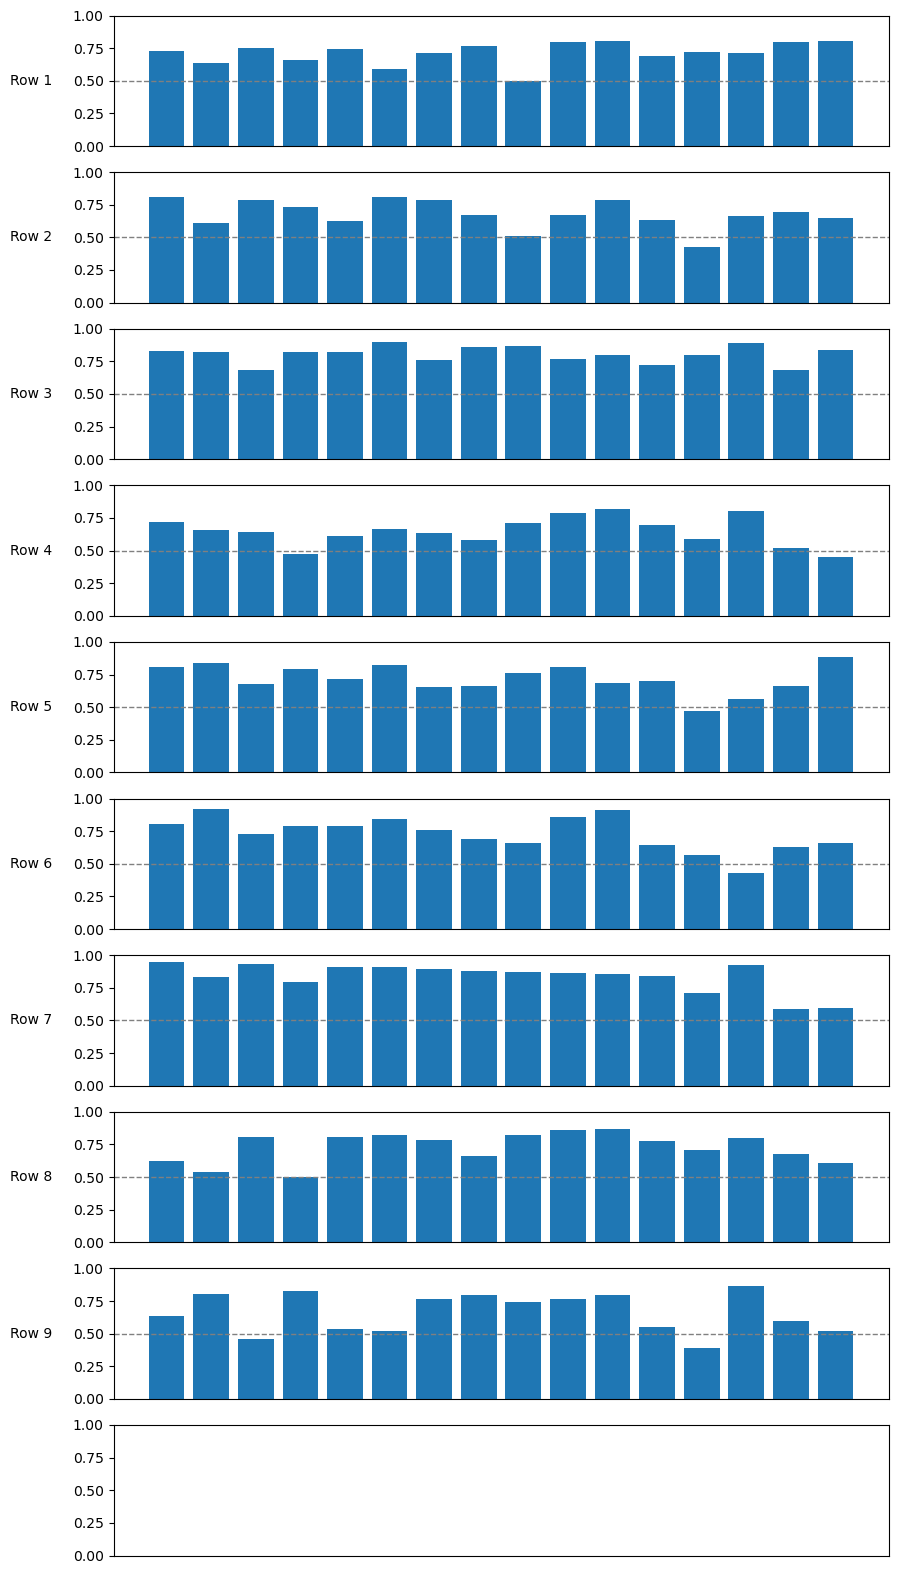

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# --- Assume accuracies_avg_toplot is already in memory ------------
try:
    accuracies_avg_toplot.shape
except NameError:
    # create demo array (4, 16, 10)
    np.random.seed(0)
    accuracies_avg_toplot = 0.5 + 0.1 * np.random.randn(4, 16, 10)

# grab the first scenario -> shape (16, 10)
data = accuracies_avg_toplot[0]            # (16 ROI, 10 rows)

roi_labels = [f"ROI{r+1}" for r in range(16)]

fig, axes = plt.subplots(10, 1, figsize=(10, 20), sharex=True)

for row in range(10):
    ax = axes[row]
    ax.bar(np.arange(16), data[:, row], color='tab:blue')
    ax.set_ylim(0, 1)
    ax.axhline(0.5, linestyle='--', color='gray', linewidth=1)
    if row == 9:
        ax.set_xticks(np.arange(16))
        ax.set_xticklabels(roi_labels, rotation=45, ha='right')
    else:
        ax.set_xticks([])
    ax.set_ylabel(f"Row {row+1}", rotation=0, labelpad=30, va='center')

fig.suptitle("Scenario 1: accuracy per ROI – 10 rows", fontsize=14, y=0.92)
fig.tight_layout(rect=[0, 0.03, 1, 0.90])



C:\Users\yujunchen\AppData\Local\Temp\ipykernel_37956\3970508492.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


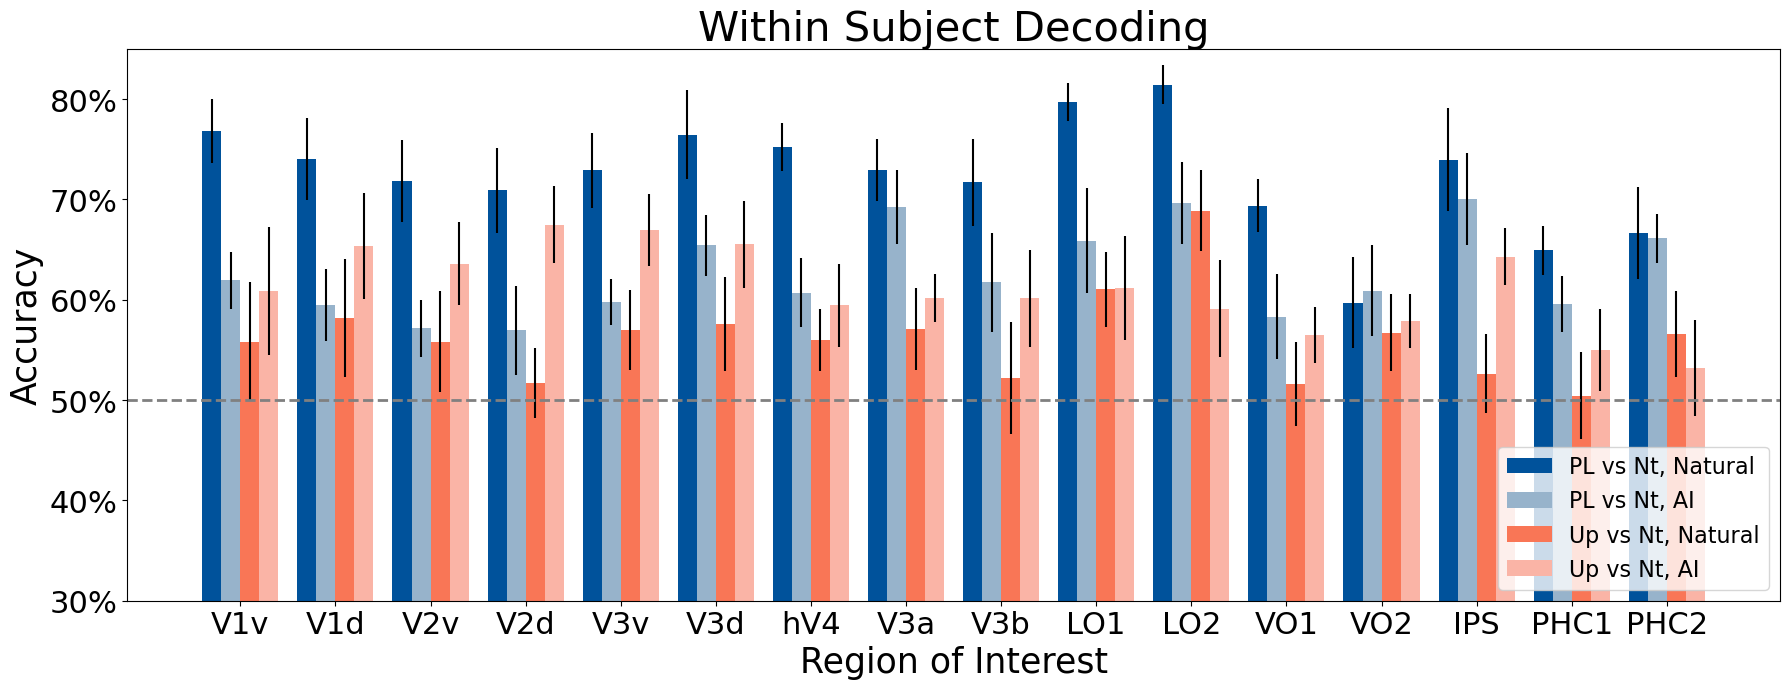

In [29]:
mean_values = np.mean(accuracies_avg_toplot, axis=2)
std_values = np.std(accuracies_avg_toplot, axis=2) / np.sqrt(accuracies_avg_toplot.shape[2])

# Define custom colors for each dataset
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

# Define legends for each comparison
legends = ['PL vs Nt, Natural', 'PL vs Nt, AI', 'Up vs Nt, Natural', 'Up vs Nt, AI']

# Create the bar chart with custom colors
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)  # Number of ROIs
rois = roi_masks.keys()
# Plot each comparison's mean values with error bars
for i in range(n_comparisons):
    ax.bar(x + i * bar_width, mean_values[i], yerr=std_values[i], width=bar_width, label=legends[i], color=colors[i])

# Set labels and title
ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)  # Set y-axis range from 0 to 1
ax.set_title('Within Subject Decoding', fontsize=30)

# Set x-ticks and labels
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)

# Format y-ticks as percentages
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

# Add horizontal line at 0.5 accuracy (chance level)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)

# Add legend
ax.legend(fontsize=16, loc='lower right')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

# Within-subject, cross-condition Decoding


## Avg over emotion

In [103]:
z_flat_sorted.shape

(11, 600, 592895)

In [ ]:
group_order = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

In [111]:
subs =          ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub11', 'Sub12']
selected_subs = ['Sub1', 'Sub2', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9', 'Sub11', 'Sub12']
# Create a mapping from selected_subs to their corresponding index in subs list
selected_indices = [subs.index(sub) for sub in selected_subs]
selected_indices

[0, 1, 3, 4, 5, 6, 8, 9, 10]

In [137]:
# Parameters
n_repeats = 20  # Number of repeats
n_folds = 4     # Number of folds in cross-validation

# Define the cross-condition comparisons you want to loop through
comparisons = [
    ('pleasant', 'neutral', 'pleasantAI', 'neutralAI'),
    ('unpleasant', 'neutral', 'unpleasantAI', 'neutralAI'),
    ('pleasantAI', 'neutralAI', 'pleasant', 'neutral'),
    ('unpleasantAI', 'neutralAI', 'unpleasant', 'neutral')
]

n_comparisons = len(comparisons)
n_rois = len(roi_masks)
n_subjects = len(selected_indices)
total_iterations = n_comparisons * n_rois * n_subjects * n_repeats * n_folds

# Initialize a dictionary to store the accuracies for each comparison and ROI
accuracy_results = {}

# Initialize the overall tqdm progress bar
with tqdm(total=total_iterations, desc="Overall Progress") as pbar:
    # Loop through the comparisons
    for condition1, condition2, condition1_cross, condition2_cross in comparisons:
        # print(f"Decoding {condition1} vs {condition2} cross with {condition1_cross} vs {condition2_cross}...")

        # Get the indices of the conditions in the group_order
        condition1_idx = group_order.index(condition1)
        condition2_idx = group_order.index(condition2)
        condition1_cross_idx = group_order.index(condition1_cross)
        condition2_cross_idx = group_order.index(condition2_cross)

        accuracy_rois = []

        # Loop through each ROI
        for m, (roi_name, roi_mask) in enumerate(roi_masks.items()):
            # print(f"Decoding ROI: {roi_name}...")

            # Flatten the ROI mask and get the indices of the ROI voxels
            flat_roi_data = roi_mask.get_fdata().flatten()
            indices = np.where(flat_roi_data)[0]

            # Extract the relevant data from z_series_sorted for the current ROI
            data = z_flat_sorted[:, :, indices]

            accuracy_subs = []

            # Loop over each subject
            for subject in selected_indices:
                subject_data = data[subject]
                condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
                condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]
                condition1_cross_trials = subject_data[condition1_cross_idx * 100:(condition1_cross_idx + 1) * 100]
                condition2_cross_trials = subject_data[condition2_cross_idx * 100:(condition2_cross_idx + 1) * 100]

                # Remove NaN columns
                condition1_trials = condition1_trials[:, ~np.isnan(condition1_trials[0, :])]
                condition2_trials = condition2_trials[:, ~np.isnan(condition2_trials[0, :])]
                condition1_cross_trials = condition1_cross_trials[:, ~np.isnan(condition1_cross_trials[0, :])]
                condition2_cross_trials = condition2_cross_trials[:, ~np.isnan(condition2_cross_trials[0, :])]

                accuracies = []

                # Perform repeats and folds of cross-validation
                for repeat in range(n_repeats):
                    kf = KFold(n_splits=n_folds, shuffle=True, random_state=repeat)
                    condition1_indices = np.arange(condition1_trials.shape[0])
                    condition2_indices = np.arange(condition2_trials.shape[0])

                    for train_idx, test_idx in kf.split(condition1_indices, condition2_indices):
                        train_indices = np.random.permutation(condition1_trials.shape[0])
                        group_indices = np.array_split(train_indices, n_folds)
                    
                        # Average trials within each group
                        train_condition1_averaged = np.array([np.mean(condition1_trials[group_idx, :], axis=0) for group_idx in group_indices])
                        train_condition2_averaged = np.array([np.mean(condition2_trials[group_idx, :], axis=0) for group_idx in group_indices])
                        # Stack the training data along the first axis
                        train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
                        train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

                        # Average trials within each group
                        test_condition1_averaged = np.array([np.mean(condition1_cross_trials[group_idx, :], axis=0) for group_idx in group_indices])
                        test_condition2_averaged = np.array([np.mean(condition2_cross_trials[group_idx, :], axis=0) for group_idx in group_indices])
                        # Stack the training data along the first axis
                        test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
                        test_labels = np.array([1] * len(test_condition1_averaged) + [0] * len(test_condition2_averaged))

                        # Train the SVM classifier
                        clf = SVC(kernel='linear')
                        clf.fit(train_data, train_labels)
                        accuracy = clf.score(test_data, test_labels)
                        accuracies.append(accuracy)

                        # Update the progress bar after each fold
                        pbar.update(1)

                # Store the average accuracy across repeats for this subject
                accuracy_subs.append(np.mean(accuracies))

            # Store the average accuracy across subjects for this ROI
            accuracy_rois.append(np.array(accuracy_subs))

        # Store the results for the current comparison
        comparison_key = f"{condition1}_vs_{condition2}_cross_{condition1_cross}_vs_{condition2_cross}"
        accuracy_results[comparison_key] = np.array(accuracy_rois)

# The final accuracy_results will contain the decoding accuracies for each comparison and ROI


Overall Progress:   0%|          | 0/46080 [00:00<?, ?it/s]

Overall Progress: 100%|██████████| 46080/46080 [02:37<00:00, 291.86it/s]


In [138]:
comparisons_order = accuracy_results.keys()

# Initialize an array to store accuracies for each comparison, ROI, and subject
n_comparisons = len(comparisons_order)
n_rois = 16  # 16 ROIs
n_subjects = 9  # 10 subjects

# Create a 3D array to hold the accuracy data: (comparisons, ROIs, subjects)
accuracies_avg = np.zeros((n_comparisons, n_rois, n_subjects))

# Fill in the accuracies_avg array with data from accuracy_results
for comp_idx, comparison in enumerate(comparisons_order):
    accuracies_avg[comp_idx, :, :] = accuracy_results[comparison]


In [139]:
# accuracies_avg_toplot = np.delete(accuracies_avg, 2, axis=2)
accuracies_avg_toplot = accuracies_avg[:,:,:6]
# accuracies_avg_toplot = accuracies_avg
accuracies_avg_toplot.shape

(4, 16, 6)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_13272\3983232002.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


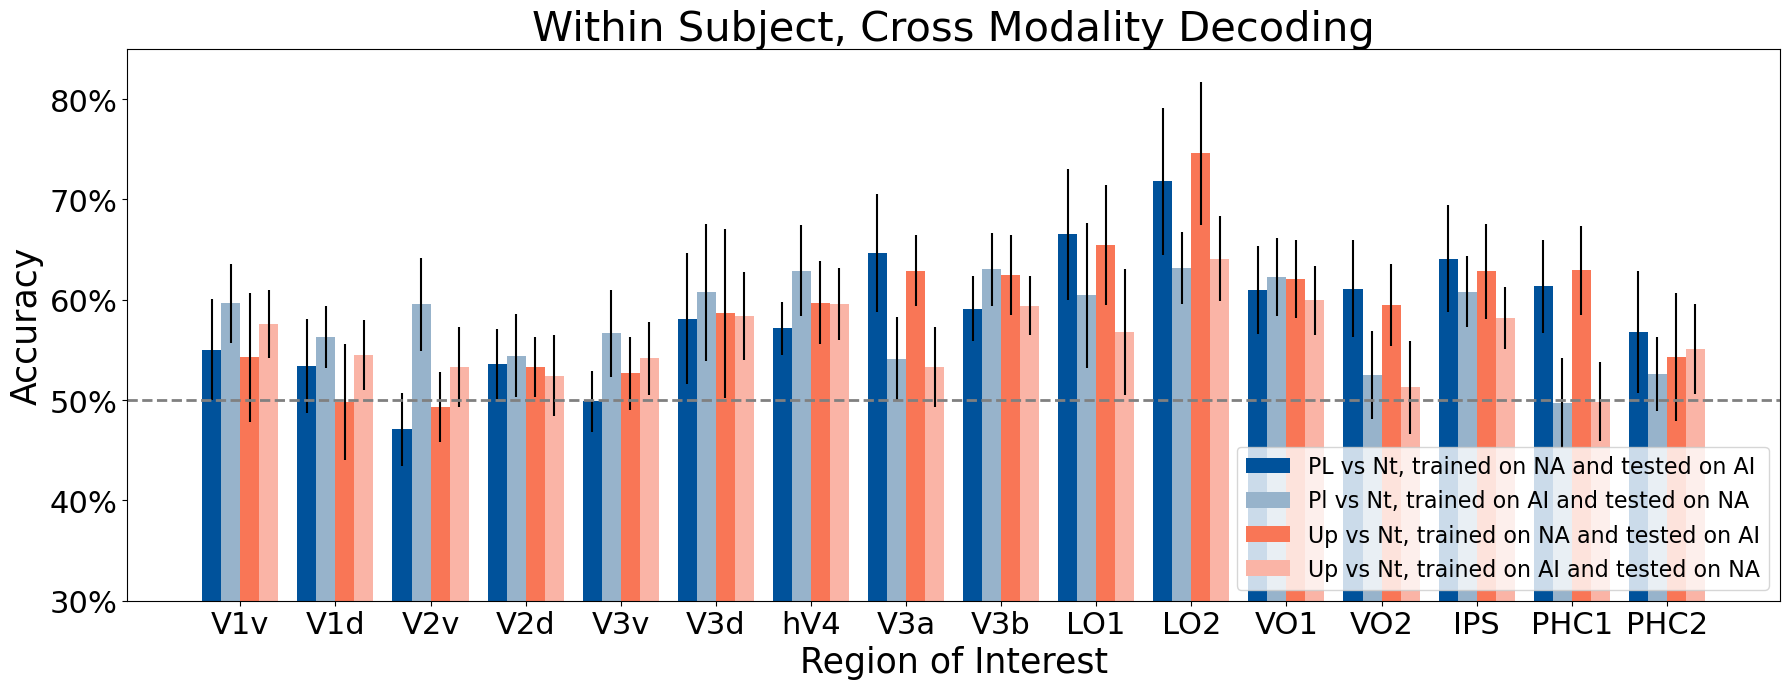

In [131]:
mean_values = np.mean(accuracies_avg_toplot, axis=2)
std_values = np.std(accuracies_avg_toplot, axis=2) / np.sqrt(accuracies_avg_toplot.shape[2])

# Define custom colors for each dataset
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

legends = []
legends.append('PL vs Nt, trained on NA and tested on AI')
legends.append('Pl vs Nt, trained on AI and tested on NA')
legends.append('Up vs Nt, trained on NA and tested on AI')
legends.append('Up vs Nt, trained on AI and tested on NA')

# Create the bar chart with custom colors
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)  # Number of ROIs
rois = roi_masks.keys()
# Plot each comparison's mean values with error bars
for i in range(n_comparisons):
    ax.bar(x + i * bar_width, mean_values[i], yerr=std_values[i], width=bar_width, label=legends[i], color=colors[i])

# Set labels and title
ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)  # Set y-axis range from 0 to 1
ax.set_title('Within Subject, Cross Modality Decoding', fontsize=30)

# Set x-ticks and labels
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)

# Format y-ticks as percentages
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

# Add horizontal line at 0.5 accuracy (chance level)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)

# Add legend
ax.legend(fontsize=16, loc='lower right')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_13272\3490784629.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


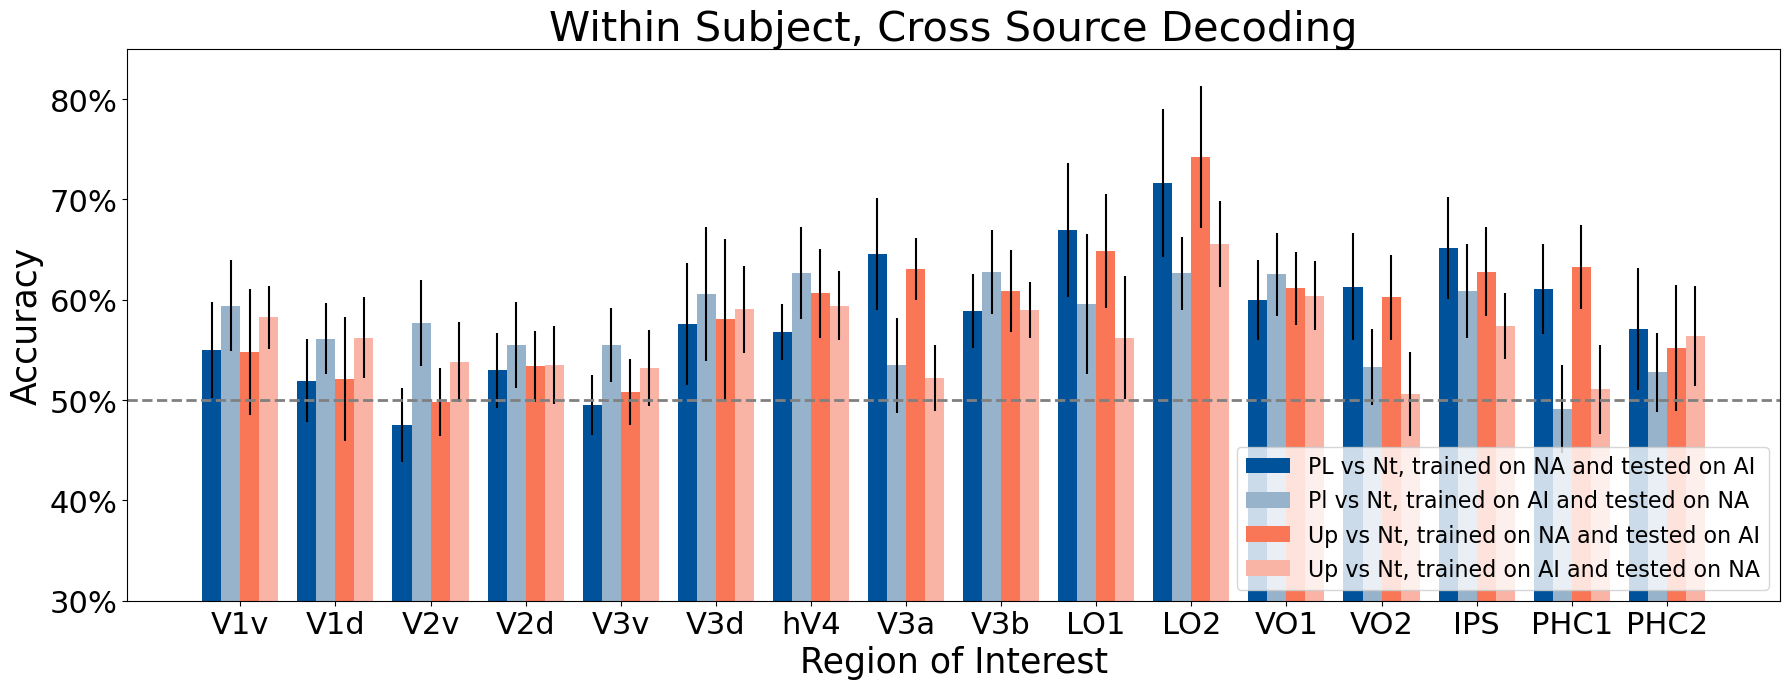

In [140]:
mean_values = np.mean(accuracies_avg_toplot, axis=2)
std_values = np.std(accuracies_avg_toplot, axis=2) / np.sqrt(accuracies_avg_toplot.shape[2])

# Define custom colors for each dataset
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

legends = []
legends.append('PL vs Nt, trained on NA and tested on AI')
legends.append('Pl vs Nt, trained on AI and tested on NA')
legends.append('Up vs Nt, trained on NA and tested on AI')
legends.append('Up vs Nt, trained on AI and tested on NA')

# Create the bar chart with custom colors
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)  # Number of ROIs
rois = roi_masks.keys()
# Plot each comparison's mean values with error bars
for i in range(n_comparisons):
    ax.bar(x + i * bar_width, mean_values[i], yerr=std_values[i], width=bar_width, label=legends[i], color=colors[i])

# Set labels and title
ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)  # Set y-axis range from 0 to 1
ax.set_title('Within Subject, Cross Source Decoding', fontsize=30)

# Set x-ticks and labels
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)

# Format y-ticks as percentages
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

# Add horizontal line at 0.5 accuracy (chance level)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)

# Add legend
ax.legend(fontsize=16, loc='lower right')

# Adjust layout and show plot
plt.tight_layout()
plt.show()